In [1]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
tqdm.pandas()

In [2]:
!python -m spacy download en_core_web_lg
nlp = spacy.load("en_core_web_lg")

     ---------------------------------------- 0.0/400.7 MB ? eta -:--:--
     ---------------------------------------- 0.3/400.7 MB ? eta -:--:--
     --------------------------------------- 3.7/400.7 MB 15.1 MB/s eta 0:00:27
      -------------------------------------- 6.6/400.7 MB 14.5 MB/s eta 0:00:28
      -------------------------------------- 8.7/400.7 MB 13.3 MB/s eta 0:00:30
     - ------------------------------------ 11.5/400.7 MB 13.2 MB/s eta 0:00:30
     - ------------------------------------ 14.2/400.7 MB 13.2 MB/s eta 0:00:30
     - ------------------------------------ 17.6/400.7 MB 13.4 MB/s eta 0:00:29
     - ------------------------------------ 20.7/400.7 MB 13.7 MB/s eta 0:00:28
     -- ----------------------------------- 22.3/400.7 MB 13.3 MB/s eta 0:00:29
     -- ----------------------------------- 26.2/400.7 MB 13.6 MB/s eta 0:00:28
     -- ----------------------------------- 28.6/400.7 MB 13.4 MB/s eta 0:00:28
     -- ----------------------------------- 31.5/400.7

In [ ]:
reviews = pd.read_csv("cleaned_comments.csv")
print(f"Loaded: {len(reviews)} rows")
reviews.head(3)

Loaded: 41440 rows


,author,updated_at,like_count,text,video_id,public,language,translated_text,is_relevant,char_count,word_count,sentence_count
0,@kingsman1713,2020-03-30T00:09:44Z,41736,The guy who stay in the ship for 20 years. He'...,j3DuONZb3Ik,True,en,The guy who stay in the ship for 20 years. he ...,True,72,16,2
1,@IkanGelamaKuning,2021-08-18T15:33:15Z,37032,A husband waiting for his wife shopping feels ...,JqKa6qyVYgg,True,en,A husband waiting for his wife shopping feels ...,True,118,22,2
2,@stevedevries2891,2021-01-05T01:33:47Z,17975,My wife keeps asking me to dust my office. I'm...,j3DuONZb3Ik,True,en,My wife keeps asking me to dust my office. I a...,True,90,22,2


In [6]:
def clean_for_ner(text):
    text = re.sub(r'[^\x00-\x7F]', '', str(text))  # remove emojis
    text = re.sub(r'\s+', ' ', text).strip()         # clean whitespace
    return text

reviews['text_for_ner'] = reviews['translated_text'].apply(clean_for_ner)
print("Done cleaning")

Done cleaning


In [7]:
def getNER(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

reviews['entities'] = reviews['text_for_ner'].progress_apply(getNER)
print("Done extracting entities")

100%|██████████| 41440/41440 [11:54<00:00, 58.04it/s]

Done extracting entities


In [28]:
import re

def normalize_entity(text):
    # remove possessives only
    text = re.sub(r"'s$|'s$", '', text.strip())
    # remove special characters and extra spaces
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # title case
    return text.title()


In [29]:
# rebuild entity counts with normalization
all_entities = [
    (normalize_entity(text), label)
    for sublist in reviews['entities']
    for text, label in sublist
]
entity_counts = Counter(all_entities)

people    = [(text, count) for (text, label), count in entity_counts.items() if label == 'PERSON']
orgs      = [(text, count) for (text, label), count in entity_counts.items() if label == 'ORG']
locations = [(text, count) for (text, label), count in entity_counts.items() if label in ['GPE', 'LOC']]
works     = [(text, count) for (text, label), count in entity_counts.items() if label == 'WORK_OF_ART']

print(f"Total unique entities: {len(entity_counts)}")
print(f"People: {len(people)} | Orgs: {len(orgs)} | Locations: {len(locations)} | Works: {len(works)}")

Total unique entities: 11238
People: 3396 | Orgs: 2233 | Locations: 570 | Works: 551


In [30]:
people_sorted    = sorted(people,    key=lambda x: x[1], reverse=True)[:15]
orgs_sorted      = sorted(orgs,      key=lambda x: x[1], reverse=True)[:10]
locations_sorted = sorted(locations, key=lambda x: x[1], reverse=True)[:10]
works_sorted     = sorted(works,     key=lambda x: x[1], reverse=True)[:10]

print("Top 15 People:",    people_sorted)
print("Top 10 Orgs:",      orgs_sorted)
print("Top 10 Locations:", locations_sorted)
print("Top 10 Works:",     works_sorted)

Top 15 People: [('Cooper', 2718), ('Nolan', 1072), ('Murph', 918), ('Miller', 444), ('Christopher Nolan', 391), ('Neil', 350), ('Mann', 327), ('Murphy', 317), ('Chris', 211), ('Gargantua', 208), ('Kip Thorne', 189), ('Matt Damon', 186), ('Hans Zimmer', 174), ('Anne Hathaway', 157), ('Tars', 154)]
Top 10 Orgs: [('Nasa', 469), ('Interstellar', 412), ('Time', 395), ('Cooper', 383), ('Coop', 243), ('Brand', 191), ('Imax', 174), ('Youtube', 150), ('Coopers', 148), ('Edmunds', 142)]
Top 10 Locations: [('Earth', 1108), ('Hollywood', 124), ('Mars', 92), ('Us', 67), ('India', 64), ('Black Hole', 52), ('The Black Hole', 50), ('Jupiter', 43), ('Manns', 30), ('America', 26)]
Top 10 Works: [('Love', 412), ('Bible', 57), ('Cooper', 46), ('Interstellar', 28), ('Batman', 25), ('Star Trek', 24), ('Nobel', 14), ('Terminator', 14), ('Oscar', 11), ('The Science Of Interstellar', 11)]


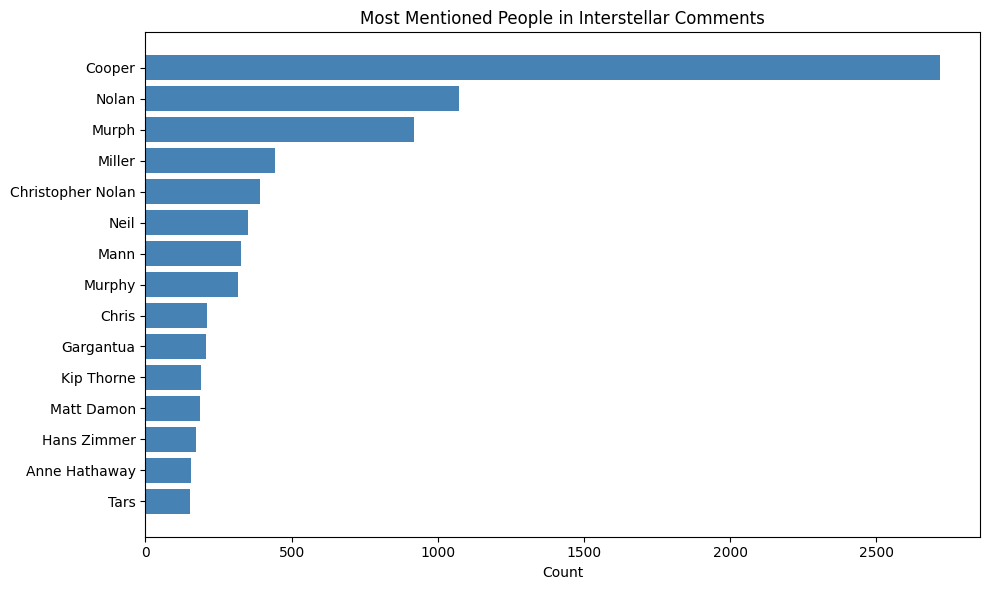

In [31]:
names, counts = zip(*people_sorted)
plt.figure(figsize=(10, 6))
plt.barh(names, counts, color='steelblue')
plt.title("Most Mentioned People in Interstellar Comments")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

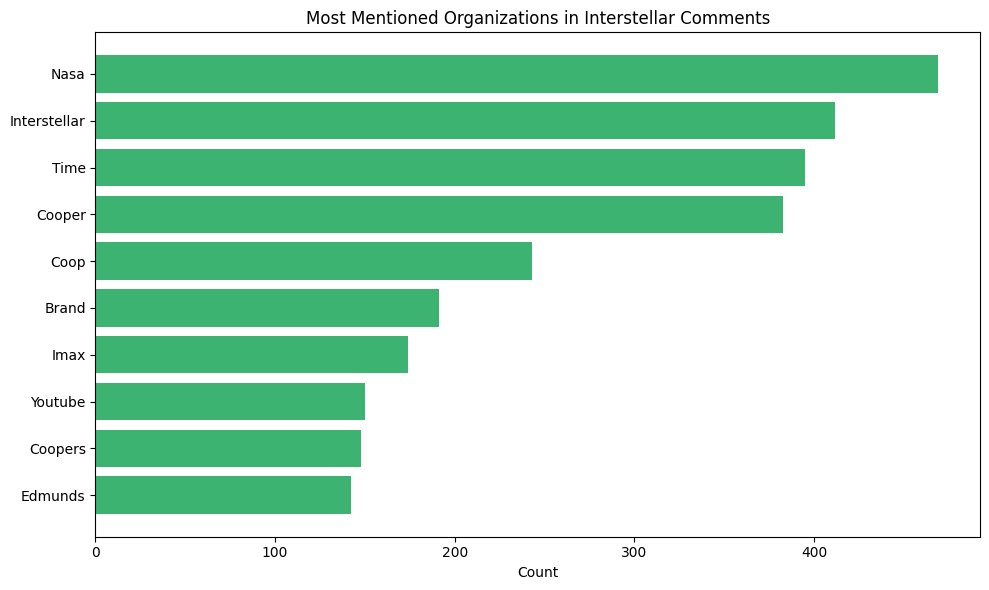

In [32]:
names, counts = zip(*orgs_sorted)
plt.figure(figsize=(10, 6))
plt.barh(names, counts, color='mediumseagreen')
plt.title("Most Mentioned Organizations in Interstellar Comments")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

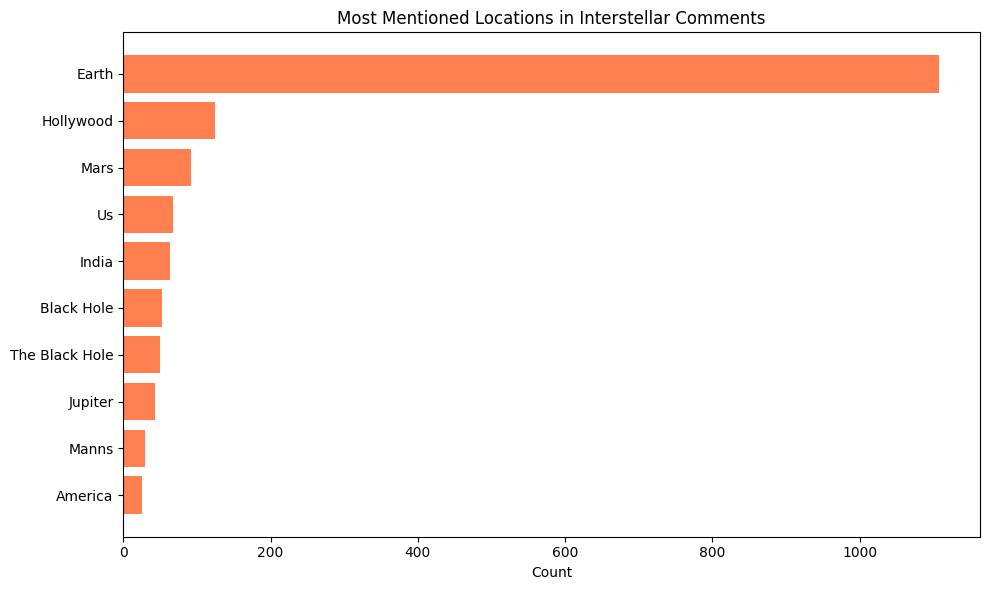

In [33]:
names, counts = zip(*locations_sorted)
plt.figure(figsize=(10, 6))
plt.barh(names, counts, color='coral')
plt.title("Most Mentioned Locations in Interstellar Comments")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

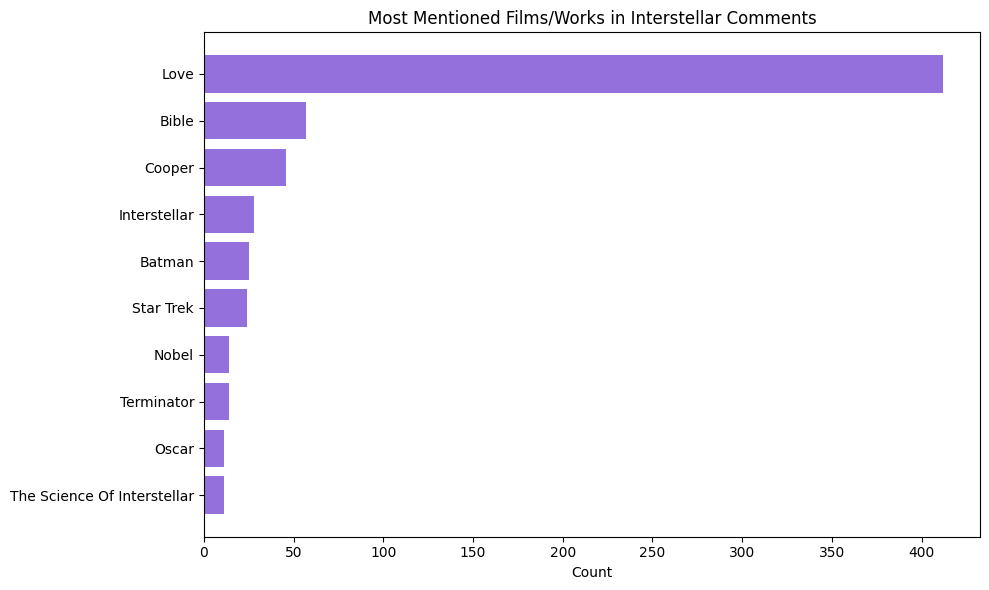

In [34]:
names, counts = zip(*works_sorted)
plt.figure(figsize=(10, 6))
plt.barh(names, counts, color='mediumpurple')
plt.title("Most Mentioned Films/Works in Interstellar Comments")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
reviews[['author', 'updated_at', 'like_count', 'text', 'translated_text', 'language', 'is_relevant', 'entities']].head()

,author,updated_at,like_count,text,translated_text,language,is_relevant,entities
0,@kingsman1713,2020-03-30T00:09:44Z,41736,The guy who stay in the ship for 20 years. He'...,The guy who stay in the ship for 20 years. he ...,en,True,"[(20 years, DATE)]"
1,@IkanGelamaKuning,2021-08-18T15:33:15Z,37032,A husband waiting for his wife shopping feels ...,A husband waiting for his wife shopping feels ...,en,True,"[(only few minutes, TIME)]"
2,@stevedevries2891,2021-01-05T01:33:47Z,17975,My wife keeps asking me to dust my office. I'm...,My wife keeps asking me to dust my office. I a...,en,True,[]
3,@joshfromdundermifflin8973,2020-03-05T18:54:19Z,15427,The scene where cooper comes back to the ship ...,The scene where cooper comes back to the ship ...,en,True,"[(cooper, PERSON)]"
4,@Dcook85,2014-11-24T01:48:48Z,15359,I was disappointed to see that Christopher Nol...,I was disappointed to see that Christopher Nol...,en,True,"[(Christopher Nolan, PERSON)]"


In [37]:
reviews[['author', 'updated_at', 'like_count', 'text', 
         'translated_text', 'language', 'is_relevant',
         'entities']].to_csv("ner_results.csv", index=False)

## Conclusion

NER on 41,440 Interstellar YouTube comments revealed meaningful patterns 
in how audiences discuss the film.

**People:** Cooper dominates as the most mentioned entity, reflecting his 
central role in the film's emotional arc. Christopher Nolan and Kip Thorne 
appear frequently, showing viewers discuss both creative vision and 
scientific credibility. Hans Zimmer's high mention count confirms the 
soundtrack is a defining part of the Interstellar experience for viewers. 
Anne Hathaway (Hathaway) and Matt Damon (Mann) round out the cast mentions.

**Organizations:** NASA leads- expected given the film's astronaut premise. 
IMAX appears frequently with viewers praising it as one of the best IMAX 
experiences ever made. Time appearing as an "organization" is a spaCy 
misclassification-  reflecting how central the concept of time is to 
viewer discussions.

**Locations:** Earth, Mars, and Jupiter confirm viewers discuss the space 
travel narrative. Black hole is heavily mentioned-  central to the plot. 
Mann's planet appears as "Mann's"- referencing the ice planet where 
Dr. Mann is stranded. Hollywood reflects viewers praising it as one of 
the best Hollywood productions. India and US suggest some viewer origin 
leakage into location entities.

**Works of Art:** Interstellar itself appears as viewers quote or reference 
the title. Batman and Terminator reflect comparisons to other iconic films. 
Nobel likely references the Nobel Prize in the context of Kip Thorne's 
scientific contributions. The Bible's presence confirms the philosophical 
and existential discussions the film provokes. "The Science of Interstellar" 
is Kip Thorne's companion book-  showing engaged viewers going beyond 
the film itself.

**Limitations:** spaCy's en_core_web_lg is trained on formal news text 
and struggles with sci-fi proper nouns. Gargantua (the black hole) was 
misclassified as a PERSON rather than a location. A transformer-based 
NER model would improve accuracy at the cost of computational resources.

**Overall:** The NER results strongly validate the project's core finding- 
viewers engage deeply with Interstellar's science, characters, soundtrack, 
and philosophical themes, going far beyond surface-level movie reactions.